# 3D-플롯

다른 포스팅에서 했던 플롯은 2차원 평면에 그래프 등을 그리는 이야기가 다뤄졌습니다.

당연히 `matplotlib`는 3차원 플롯도 지원하며, 이를 위해서 하위 모둘 `mpl_toolkits`의 하위 모둘 `mplot3d`이 열일합니다.

이 하위 하위 모둘로부터 우리는 `Axes3D`라는 객체를 임포트해야합니다.

```python
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
```
이걸 이용해서 어떻게 3D 플롯을 하는지 다음의 예시 함수로부터 출발해볼게요.

$$ z(x,y) = x^2 + y^2$$

일단 3D 플롯의 과정을 모두 나열해보면 다음과 같습니다.

1. `fig = plt.figure()`을 이용하여 기존의 플롯에서처럼 우선 `figure`를 생성함.
2. 그리고 이 `figure` 안에서 `fig.add_subplot(projection = '3d')`를 이용하여 3D 플롯임을 알려줌.(3D 전용 플롯 칸을 만드는 명령어입니다.)
3. `fig.add_subplot(projection = '3d')`는 `Axes`라는 객체를 반환하는데, 여기에 `plot_surface()` 를 이용하여 3D 플롯에 대한 정보를 전달한다.

뭔가 복잡해보이지만, 간단합니다.

기존에는 그냥 바로 `plt.plot()`에다가 `x,y` 정보를 입력하면 2차원 플롯이 되었는데요,

3차원 플롯을 위해서는 `fig.add_subplot(projection = '3d')`라는 명령어가 추가로 필요합니다.

원래 `fig.add_subplot()`은 이름부터 자명하지만, 서브 플롯(하나의 figure에 여러 플롯을 넣기 위해)을 추가하는 명령어인데요,

3D 플롯의 맥락에서는 그거보다는 `projection = '3d'`와 함께 3D 플롯을 위한 전용 칸을 만들어라는 명령으로 사용됩니다.

이렇게 공간을 우선 확보한 다음, 거기에 `plot_surface()`에 이제는 `x,y,z`라는 3차원 정보를 넘겨서 3D 플롯을 만드는겁니다.

무엇보다도 이 넘겨지는 `x,y,z`는 단순한 리스트나 1차원 배열이 아닌, 행렬 형태의 2차원 배열입니다.

그 이유는 간단해요. 우리는 기본적으로 $\mathbb{R}^2 \to \mathbb{R}$의 형태의 함수를 3D 플롯하는데요,

이에 따라서 정의역의 부분은 2차원 평면이고, 우리는 그 2차원 평면 위의 함수 값 지점을 골라서 입체적인 형태로 그래프를 그리게 됩니다.

기존에는 정의역이 1차원 수직선이었어서, 1차원의 수직선을 쪼개가지고 그 위에 함수 값들을 잡고, 그들을 잇는 방법으로 그래프를 그렸으나,

이제는 정의역의 부분이 평면이다보니 이 평면을 마치 방충망처럼 조밀하게 쪼개서, 그 쪼개진 지점 위에서 함수 값을 잡아야하는겁니다.

예를 들어서, 평면 위에 총 $n\times n$개의 점을 찍는다고 해볼게요. 그러면 그 쪼개진 점들은  $i,j\in \{1,...,n\}$에 대해서 

$p_{ij}$라는 형태로 표현할 수 있습니다. 이 $p_{ij}$는 모두 2차원 평면 상의 점이니, $p_{ij} = (x_i,y_j)$의 형태로 표현이 가능한데요,

우리는 이제 이러한 `p_{ij}`의 점의 $x$축 좌표 $x_i$를 모두 모으고, $y$축 좌표 $y_j$를 모아서, 이들을 각각 `x,y`에 넣는겁니다.

다시 말해서, `plot_surface(x,y,z)` `x`의 `x[i,j]`는 정의역 평면을 쪼갠 점들 중 `(i,j)`번째 점의 `x`좌표를 의미합니다.

`y`도 마찬가지이구요.

그 점들의 정보를 토대로 비로서 `z`는 그 `p_{ij} = (x_i,y_j)`에서의 함수값 `z_{ij}`를 포함한 2차원 배열이 형태가 되는겁니다.

그러면 여기서 문제는 `x,y`를 어떻게 생성하냐일텐데요, 그 방법도 간단합니다.

우선 우리는 `x`에 정의역을 `x`축 방향으로 쪼갠 친구들을 모으고, `y`에는 `y`축 방향으로 쪼갠 친구들을 모읍니다.

이 시점에서 `x,y`는 그저 1차원의 배열에 지나지 않습니다.

그리고 우리는 이 1차원 배열들에 카르테지안 곱 비슷한 연산을 해주면 비로소 2차원 평면의 격자점들을 얻을 수 있는데요, 이는 다음 함수가 활용됩니다.

```python
x,y = np.meshgrid(x,y)  # 좌변의 x,y랑 우변의 함수 안에 들어있는 x,y는 구조적으로 서로 다른 놈입니다.
```
`np.meshgrid()`함수는 1차원 배열을 두 개 받아서, 이들을 통한 카르테지안 곱 형태의 격자점을 저장하여 2차원 배열을 두 개 내보냅니다.

그 각각이 `x,y`가 되고, 이 `x,y`는 모두 2차원 배열이 되는거에요.

근데 이렇게 생각할 수 있어요. 왜  `x,y`가 모두 2차원 배열이어야함? 그냥 진짜 수학의 카르테지안 곱처럼해서, 2차원 배열 하나로 퉁칠 수 있는거 아니냐?

맞는 말인데요, 그건 `matplotlib`랑 `NumPy`의 표준을 `x,y` 둘 모두를 2차원 배열로 하기로 정했기 떄문입니다. 

그 이유는 좀 깊은 설명이 필요해서, 그냥 그렇구나 하고 넘어가도록 하겠습니다.

여튼 저렇게 `meshgrid`를 하면, `x`에는 $x$축의 값들이 행을 따라 가로로 반복되고, `y`는 `y`축의 값들이 열을 따라 세로로 반복되는 2차원 배열이 들어있습니다.

위에서 설명한 과정들을 함수 $z = x^2+y^2$에 대해 해볼게요.

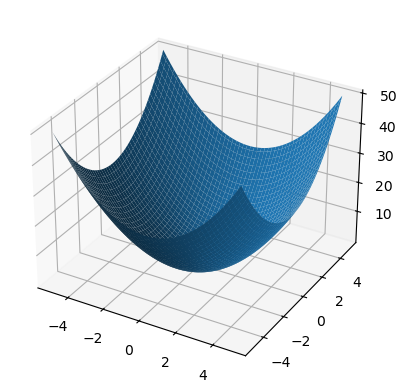

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# x,y를 우선 1차원 배열로 정의
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)

# meshgrid를 사용한 이후부터 x,y에는 각각 100x100 형태의 2차원 배열들이 각각 들어있음.
x, y = np.meshgrid(x, y)

# 배열의 점별 연산을 적용하여 Z라는 2차원 배열을 정의
z = x**2 + y**2

# 위에서 설명한 그 과정대로 플롯
fig = plt.figure()
ax = fig.add_subplot(projection='3d') # 유의할 점이 있는데요, 3D 플롯은 기본적으로 객체 지향으로 동작하므로 메소드로 이용하셔야합니다!
ax.plot_surface(x, y, z)
plt.show()

이러한 3D 플롯에는 기존의 2D 플롯으로 하던거처럼, 색깔, 격자, 선의 굵기, 타이틀, 축의 이름 등등을 지정해줄 수 있습니다.

이를 위한 메소드들은 다시 한 번 정리하자면 다음과 같습니다.

- `set_xlabel`, `set_ylabel`, `set_zlabel` : 각각 `x`, `y`, `z`축의 이름을 정함
- `set_xlim`, `set_ylim`, `set_zlim` : 각 축들의 가시 범위를 지정(파라미터로 가시 범위의 min, max를 넣어줌)
- `set_xticks`, `set_yticks`, `set_zticks`: 각 축들을 어떻게 쪼갤 지(각 축의 가시 범위에서 쪼개질 위치를 지정)
- `set_xticklabels`, `set_yticklabels`, `set_zticklabels` : 쪼개진 놈들에 숫자를 어캐 붙일지(위에서 쪼개진 위치에 뭘 적을지를 지정)
- `plt.legend` : 범례(어떤 그래프가 어떤 함수건지의 정보)를 표시
- `plt.title` : 플롯의 타이틀을 지정
- 그리고 이 메소드들 안에 매개변수로는 다음의 친구들을 지정해줄 수 있습니다.
    - `color`
    - `alpha`
    - `linewidth`
    - `linestyle`
    - `marker`
    - `markersize`
    - `fontsize`

**주의할 점** : 2D 플롯에는 그냥 위의 놈들을 함수로 사용하면 됐었는데요, 위 코드 주석에서도 설명한대로 3D 플롯은 기본적으로 객체 지향으로 동작하므로
함수가 아닌 메소드로 사용해주셔야합니다. 이 때, 메소드가 적용되는건 우리의 서브 플롯 `ax`입니다.

위 코드에서 저것들을 사용하여 다음과 같은 플롯을 그릴 수 있습니다.

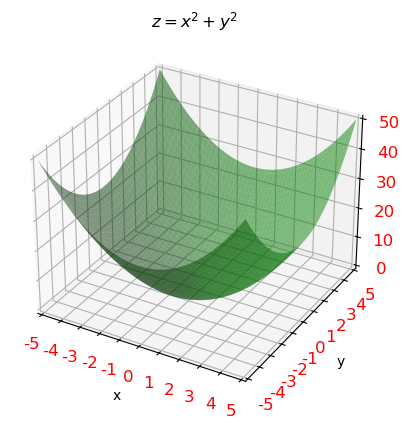

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
x, y = np.meshgrid(x, y)
z = x**2 + y**2

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# 이까지는 위와 완전 동일

# 아래부터는 방금 설명한 옵션들을 이용해서 플롯을 좀 더 이쁘게 만듬
ax.plot_surface(x, y, z, color='green', alpha=0.5, linewidth=2)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_zlim(0, 50)
ax.set_xticks(range(-5, 6, 1))
ax.set_yticks(range(-5, 6, 1))
ax.set_zticks(range(0, 51, 10))
ax.set_xticklabels(range(-5, 6, 1), fontsize=12, color='red')
ax.set_yticklabels(range(-5, 6, 1), fontsize=12, color='red')
ax.set_zticklabels(range(0, 51, 10), fontsize=12, color='red')
ax.set_title(r'$z = x^2 + y^2$') # 참고로 `title`의 스트링에 라텍스처럼 $$를 하면 알아서 수식으로 변환해줌 보통 보시다시피 raw string을 사용하는 게 좋음.
plt.show()

### 플롯의 원리를 좀 더 자세히

플롯을 할 떄, 우리는 계속 `import mathplotlib.pyplot as plt`를 이용했는데요,

`mathplotlib.pyplot`이라는건 `mathplotlib`라는 모둘에 포함되어 있는 인터페이스라고 불리는 `pyplot`를 불러오겠다는 소리입니다.

`pyplot`는 플롯을 위한 도구들을 모은 함수들의 모임이에요. 우리가 플롯을 가능하게 해주는 기본적인 단위들은 모두 `pyplot`의 객체들입니다 :

- `Figure` : 플롯이 그려질 창을 의미(인터넷 브라우저의 새 창을 생각하시면 됩니다. 서브 플롯을 추가하는건 탭을 추가하는 느낌)
- `Axes` : 플롯 그 자체이자, 정확히 말하면 플롯에 관한 모든 정보(축, 눈금, 레이블, 그래프를 그리는 점과 선)를 모두 담는 그릇

`Axes`를 생성할 때 사용 가능한 `Figure`가 없다면 새로운 `Figure`가 자동으로 하나 생성됩니다. 그래서 우리는 기존에 2D 플롯을 하나 그리는 경우

굳이 굳이 `plt.figure()`로 먼저 새 창을 연 후에 `plt.plot()`을 하지 않아도 됐던겁니다.

또 2차원 플롯에서는 `Axes`도 따로 언급되지 않았는데요, 2D 플롯의 경우에는 플롯 시에 `Figure`이 자동 생성되는거처럼 `Axes`도 자동 생성되었기 떄문입니다.

그래서 그냥 `Axes`는 그냥 알아서 생성되니 따로 언급할 필요도 없고, 그나마 새 창을 여는 `plt.figure()`만 사용됐던거죠.

하지만 특별한 성질들을 가진 플롯을 생성할 때에는 `Figure`과 `Axes`를 명시적으로 생성하고, 명령도 얘네한테 해줘야합니다.

이 "특별한 성질을 가진 플롯"의 일종이 바로 우리가 지금 다루는 3D 플롯인거에요.

따라서 3D 플롯에서는 항상 위에서 했던거처럼 `Figure`, `Axes3D`(`Axes`의 3D 버젼)를 명시적으로 생성하고, 플롯을 수정하거나 기능을 추가할 떄에도

이 명시적으로 생성된 인스턴스에 직접 참조하여 메소드를 이용해야 하는겁니다.

`plt.<...>` 형태의 명령어들은 모두 `pyplot`의 메소드/함수들로, `Figure`과 `Axes`를 생성 및 수정하기 위한 기능들이 포함되어 있습니다.

`Figure`랑 `Axes3D`를 생성하는 부분을 다시 보시죠.

```python
fig = plt.figure()
ax = fig.add_subplot(projection = '3d')
```

이건 결국 `fig`라는 이름의 새 창을 하나 열고, 그 창 위에 `fig.add_subplot(projection = '3d')`의 형태의 이름이 `ax`인 `axes`를 하나 생성한단겁니다.

`add_subplot()`은 위에서도 설명한대로, 여기선 일단 3D 플롯임을 알려주는 역할을 하나, 동시에 서브 플롯을 구성시켜 칸을 나누는 역할도 합니다.

따라서 만약 다음과 같이 사용한다면, `ax1`, `ax2`는 `fig` 창에서 각각 1행 1열, 1행 2열의 3D 서브 플롯들이 됩니다.

```python
fig = plt.figure()
ax1 = fig.add_subplot(1,2,1,projection = '3d')
ax2 = fig.add_subplot(1,2,2,projection = '3d')
```

`ax1`의 경우의 `1,2,1`은, 결국 `fig`의 창을 1행 2열로 나눠서, 우리의 `ax1`은 그 중 인덱스가 1인 칸에 두라는 의미이고,

`ax2`는 마찬가지로 나뉜 `fig`에서 인덱스가 2인 칸에 두라는 의미가 됩니다.

`fig.add_subplot()`의 첫번째 세 매개 변수들은 `row, column, index`가 됩니다. 

이렇게 되면 `fig`는 1행 2열로 나뉘어서, 각 열에 서로 다른 플롯을 동시에 걸 수 있게 되며, `index`는 그 칸들의 위치(1행 2열의 오른쪽 왼쪽)의 인덱스입니다.

참고로 인덱스는 왼쪽에서 오른쪽으로, 위에서 아래로 가면서 커집니다. 예를 들어 `row = 5`, `column = 4`인 `figure`의 인덱스는 다음과 같습니다.

|  | 1열 | 2열 | 3열 | 4열 |
| :---: | :---: | :---: | :---: | :---: |
| 1행 | index = 1 | index = 2 | index = 3 | index = 4 |
| 2행 | index = 5 | $\cdots$ | $\cdots$ | index = 8 |
| 3행 | $\vdots$ |$\ddots$ |  | $\vdots$ |
| 4행 | $\vdots$ |  | $\ddots$ | $\vdots$ |
| 5행 | index = 17 | $\cdots$ | $\cdots$ | index = 20 |

이건 2D 플롯이랑 동일하죠.

여튼 이렇게 다음과 같이 두 플롯을 한 번에 같은 `Figure`에 플롯할 수 있습니다

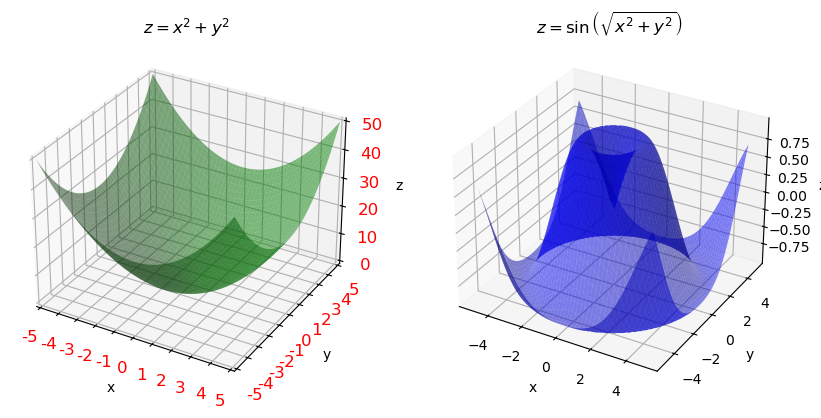

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# 일단 범위는 동일하게 할 예정
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
x, y = np.meshgrid(x, y)

# 우선 첫번째 함수로는 기존의 z = x^2+y^2을 사용
z1 = x**2 + y**2

fig = plt.figure(figsize=(10, 6))

# First subplot
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(x, y, z1, color='green', alpha=0.5, linewidth=2)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
ax1.set_xlim(-5, 5)
ax1.set_ylim(-5, 5)
ax1.set_zlim(0, 50)
ax1.set_xticks(range(-5, 6, 1))
ax1.set_yticks(range(-5, 6, 1))
ax1.set_zticks(range(0, 51, 10))
ax1.set_xticklabels(range(-5, 6, 1), fontsize=12, color='red')
ax1.set_yticklabels(range(-5, 6, 1), fontsize=12, color='red')
ax1.set_zticklabels(range(0, 51, 10), fontsize=12, color='red')
ax1.set_title(r'$z = x^2 + y^2$')

# Second subplot
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

z2 = np.sin(np.sqrt(x**2 + y**2))
ax2.plot_surface(x, y, z2, color='blue', alpha=0.5, linewidth=2)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('z')
ax2.set_title(r'$ z = \sin\left(\sqrt{x^2 + y^2}\right)$') # 이렇게 수식 스트링 안에 \가 오는 경우, 이스케이프 시퀀스를 피하기 위해 raw string이 좋음

plt.show()

위에서 설명한 이야기는 굳이 3D 플롯에만 국한되는 게 아니구요, 기존의 2D 플롯도 마찬가지입니다.

따라서 서브 플롯을 나눌 떄에는 기존에서처럼 어디에다가 뭘 적용하는지 뭔가 불명확했던 방식 대신에,

다음과 같이 `figure`, `axes`를 명시적으로 다루는 방법을 사용하는 게 더 편할 수 있습니다.

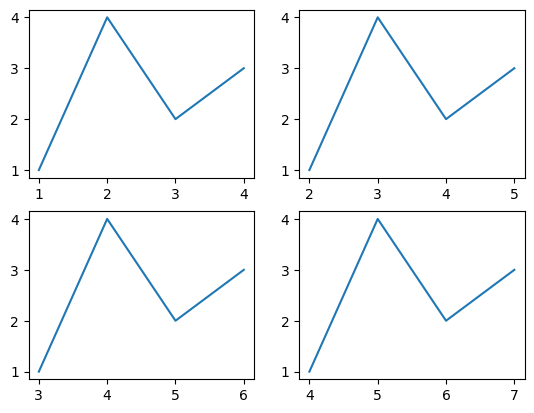

In [4]:
fig = plt.figure()
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax4 = fig.add_subplot(2, 2, 4)

ax1.plot([1, 2, 3, 4], [1, 4, 2, 3])
ax2.plot([2, 3, 4, 5], [1, 4, 2, 3])
ax3.plot([3, 4, 5, 6], [1, 4, 2, 3])
ax4.plot([4, 5, 6, 7], [1, 4, 2, 3])

plt.show()

## 3D-표면(`plot_surface()`)

뭐 `figure`과 `axes`는 그렇다치고, 결국 그 `axes`에 3D 그래프를 그리는 놈은 `plot_surface()`였는데요,

이 놈은 이름처럼 3D 표면을 그리는 놈이지, 3차원 함수 그래프만을 그리는 친구가 아닙니다.

따라서 우리는 함수랑 상관없는 3차원 표면을 그리는대에도 해당 메소드를 사용할 수 있습니다.

예를 들어서 단위 구(Unit Sphere)의 방정식은 다음과 같이 주어집니다.

$$
x^2 + y^2 + z^2 = 1 $$ 

이 친구는 원의 방정식과 마찬가지로, 함수는 아닙니다. 하지만 다음과 같이 파라미터화가 가능하죠.
$$ x = \cos(u) \sin(v), \quad y = \sin(u) \sin(v), \quad z = \cos(v), \quad \text{where } u \in [0, 2\pi], v \in [0, \pi]$$

이걸 이용하면 우리는 단위 구를 다음과 같이 그려볼 수 있습니다.

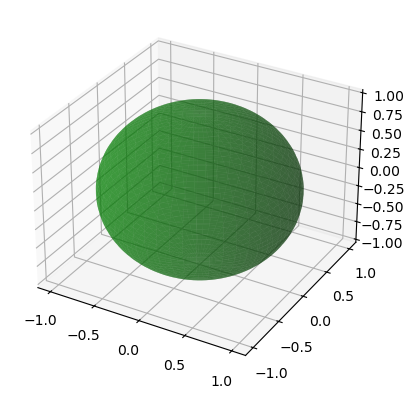

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# u축, v축을 100개로 분할
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)

# u,v에 대한 사인/코사인 값을 미리 구함
cos_u = [np.cos(ui) for ui in u]
sin_u = [np.sin(ui) for ui in u]
sin_v = [np.sin(vi) for vi in v]
cos_v = [np.cos(vi) for vi in v]

# u,v는 파라미터고, 이걸 x,y에 대한 형태로 변환해야하기 떄문에, 이번엔 다음과 같이 수동으로 meshgrid() 없이 2차원 배열을 구성합니다.
x = np.array([[cu * sv for sv in sin_v] for cu in cos_u])
y = np.array([[su * sv for sv in sin_v] for su in sin_u])

# 물론 위의 과정들은 np.cos(), np.sin()이 유니버셜 함수임을 활용해서도 해결 가능합니다. 아래 코드에서 다뤄짐

# z에 대해서도 마찬가지 방법으로 2차원 배열을 구성합니다.
z = np.array([[1 * cv for cv in cos_v] for _ in u]) # for _ in u는 u를 직접 사용하지 않고 저걸 반복하겠다는 의미입니다. 애초에 z는 u에 의존적이지 않죠.


fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(x, y, z, color='green', alpha=0.5, linewidth=2)
plt.show()

간단합니다. `x,y,z`를 구성하는 방법은 주석을 보시면 되는데요,

저건 구성되는 과정 자체를 좀 명확하게 보여드리기 위한 조치이고, 그냥 `np.meshgrid()`를 사용해서 다음과 같이 구현도 가능합니다.

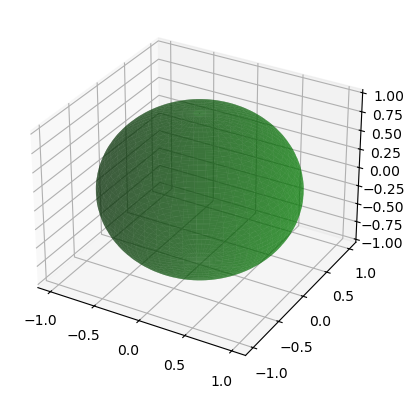

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# 똑같이 u,v를 분할하고
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)

# 그 u,v로 meshgrid()를 한 후,
u, v = np.meshgrid(u, v)

# x,y,z에는 u,v를 이용해서 유니버셜 함수를 적용 후, 행렬간의 성분간 곱으로 해결 가능
x = np.cos(u) * np.sin(v)
y = np.sin(u) * np.sin(v)
z = np.cos(v)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(x, y, z, color='green', alpha=0.5, linewidth=2)
plt.show()

우리는 위와 같은 플롯에다가 기존의 2D 플롯에서처럼 다른 그래프나 점의 플롯을 겹치는거도 가능합니다.

이는 이제 우리가 `axes`의 개념을 알기 떄문에 어떻게 할지 간단하죠. 단위 구의 `axes`에 추가적인 플롯을 더해주면 됩니다 : 

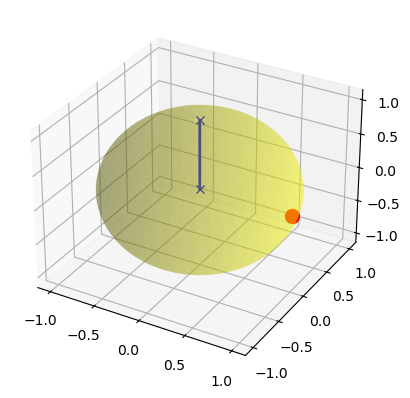

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D


u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)

u, v = np.meshgrid(u, v)

x = np.cos(u) * np.sin(v)
y = np.sin(u) * np.sin(v)
z = np.cos(v)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(x, y, z, color='yellow', alpha=0.3, linewidth=2, zorder = 1)

# 이 위까지는 기존의 코드와 동일합니다.
#  기존의 단위 구가 그려지는 axes인 ax에 다음과 같이 추가적인 scatter와 plot을 더할 수 있습니다.
ax.scatter([1], [0], [0], color='red', s=100, zorder = 10, depthshade =False)
ax.plot([0, 0], [0, 0], [0, 1], color='blue', marker='x' , linewidth=2)
plt.show()

저렇게 기존의 2D 플롯을 위해 사용하던 놈들을 쓰셔도 되구요, 또 다른 표면을 그리셔도 됩니다.

2D 플롯에서 계속해서 겹치지던건 `axes`에 저렇게 계속해서 다른 그래프의 플롯들이 추가되기 떄문인겁니다.

이를 이용하시면 다음과 같은 깔쌈한 원기둥을 타고 올라가는 나선도 그릴 수 있습니다

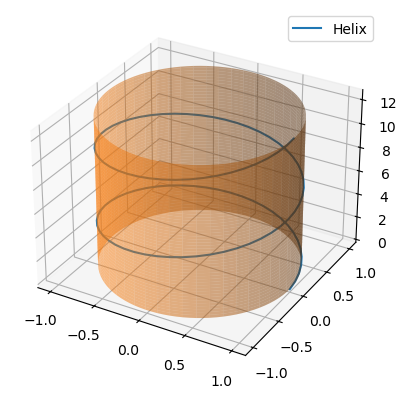

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

t = np.linspace(0, 4 * np.pi, 100)
x = np.cos(t)
y = np.sin(t)
z = t

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot(x, y, z, label='Helix')


theta = np.linspace(0, 2*np.pi, 100)
z = np.linspace(0, 4 * np.pi, 100)
theta, z = np.meshgrid(theta, z)

x_vals = np.cos(theta)
y_vals = np.sin(theta)
z_vals = z

ax.plot_surface(x_vals, y_vals, z_vals, alpha=0.5)

ax.legend()
plt.show()

## 3D 플롯 더보기 리그

위의 `plot_surface()` 메소드는 3차원 함수를 그냥 매끈한 곡면처럼 만들어내는 기능을 했습니다.

근데 경우에 따라서 매끈하게 말고, 다른 방식으로도 3D 플롯이 필요할 수 있는데요,

이를 위한 메소드로 다음 두 친구를 다뤄보려고 합니다.

```python
ax.plot_wireframe(x,y,z)
ax.contour3D(x,y,z)
```

이 메소드들은 `plot_surface()`와 동일한데, 그냥 결과물만 다르게 만들어주는 친구들입니다. 

2차원 배열 `x,y,z`이라는 밀가루로 `plot_surface()`가 칼국수를 만든다면, 쟤네들은 수제비나 파스타를 만드는 그런 느낌이죠.

### 3D-Wireframe

3D-Wireframe 플롯은 우리의 격자점 `x,y`위의 값 `z`끼리 선분을 이은 3D 격자 형태 위에서의 함수의 플롯을 의미합니다.

그냥 눈으로 보시면 더 빨라요. 설명한대로 `plot_surface()`랑은 완전히 재료가 같으니,

긴 말 하지 않고 위에서 했던 $z = x^2 + y^2$를 그대로 `plot_wireframe()`으로만 바꿔서 한 번 실행해볼게요.

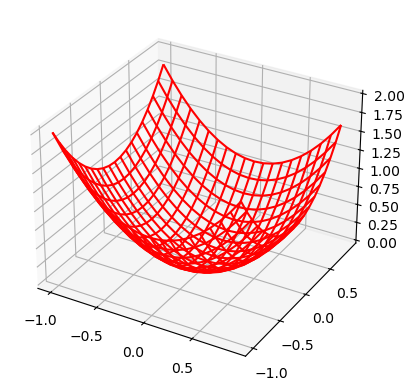

In [9]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
X = np.arange(-1, 1, 0.1)
Y = np.arange(-1, 1, 0.1)
X, Y = np.meshgrid(X, Y)
Z = X**2 + Y**2
ax.plot_wireframe(X, Y, Z, color='r')
plt.show()

설명한대로입니다. `plot_surface()`는 저 면을 매끈하게 그리지만, 얘는 저렇게 그냥 함수값들을 이은 형태를 그립니다.

### 등고선

등고선, 혹은 3D-contour 플롯은 말 그대로 등고선이 보이도록 플롯하는걸 의미합니다.

등고선은 결국 함수 $z(x,y)$에 대해서, $z(x,y) = c$인 모든 $(x,y)$들이 모여서 만드는 점을 의미합니다.

여러분들이 지도에서 보는 바로 그 등고선이에요.

우리는 현실의 산을 좌표화해서, $(x,y)$라는 지점(2차원 평면 좌표)에서 산의 높이를 함수 $z(x,y)$로 표현할 수 있는데요,

높이가 200인 등고선은 $z(x,y) = 200$을 만족하는 $(x,y)$가 그리는 곡선입니다. 그걸 지도에 그린 게 여러분들이 아시는 그 등고선이에요.

얘도 보면 이해가 빠릅니다. 똑같이 $z = x^2+y^2$로 구현해볼게요 :

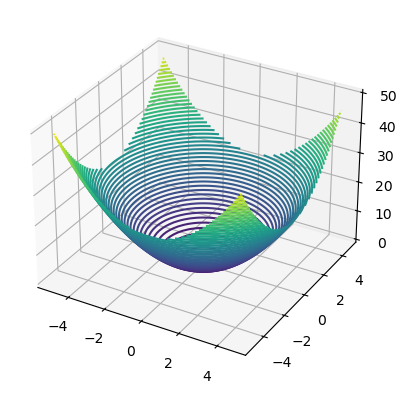

In [10]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
X = np.arange(-5, 5, 0.25)
Y = np.arange(-5, 5, 0.25)
X, Y = np.meshgrid(X, Y)
Z = X**2 + Y**2
ax.contour3D(X, Y, Z, 50)
plt.show()

대충 이해가 되지 않나요? 저 표면은 결국 파란색과 초록색, 노란색 등의 원형 고리 같은 친구들이 각 z 값(세로축)을 기준으로 그려진 형태입니다.

저렇게 함수값이 같은 놈들이 그리는 $xy$평면과 평행한 선들을 모아서 그리는거에요.

참고로 위에서는

```python
ax.contour3D(x,y,z 50)
```

형태로 50이 들어있는데요, 이는 등고선이 총 50개가 되도록 그리라는 명령입니다.

여튼 `ax.plot_surface`을 포함하여 `ax.contour3D`,`ax.plot_wireframe`들은 모두 같은 방법으로 색깔, 격자, 선의 굵기, 타이틀 등을 설정할 수 있습니다.

참고로 색깔은 `color = `의 방법으로도 지정 가능하나, `cmap`이라는 옵션을 사용할 수도 있습니다.

`cmap`은 단순한 단색 칼라가 아니라, 특정 색깔을 베이스로한 칼라 맵(Color map)을 보여줍니다.

이 옵션을 사용하면 단색이 아니라, `z`값의 크기/밀도를 고려하여, 그라데이션의 느낌으로 그래프를 그려줍니다. 

다음 코드에서 이 `cmap`에서 가장 자주 사용되는 칼라 맵들이 어떤 친구가 있는지를 확인하실 수 있습니다.

물론 이는 3D 등고선 뿐 아니라, 와이어 프레임이나 표면에도 똑같이 사용 가능합니다.

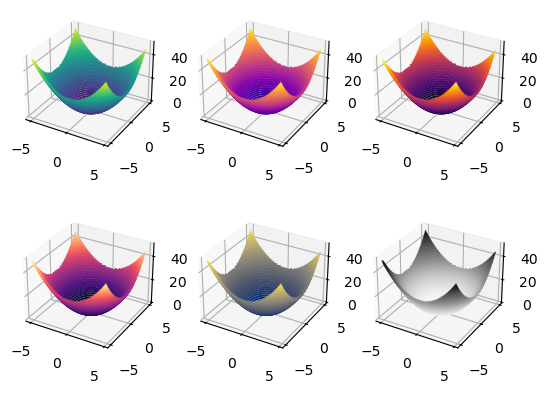

In [11]:
fig = plt.figure()
ax1 = fig.add_subplot(231, projection='3d')
X = np.arange(-5, 5, 0.25)
Y = np.arange(-5, 5, 0.25)
X, Y = np.meshgrid(X, Y)
Z = X**2 + Y**2
ax1.contour3D(X, Y, Z, 50, cmap = 'viridis')

ax2 = fig.add_subplot(232, projection = '3d')
ax2.contour3D(X, Y, Z, 50, cmap = 'plasma')

ax3 = fig.add_subplot(233, projection = '3d')
ax3.contour3D(X, Y, Z, 50, cmap = 'inferno')

ax3 = fig.add_subplot(234, projection = '3d')
ax3.contour3D(X, Y, Z, 50, cmap = 'magma')

ax3 = fig.add_subplot(235, projection = '3d')
ax3.contour3D(X, Y, Z, 50, cmap = 'cividis')

ax3 = fig.add_subplot(236, projection = '3d')
ax3.contour3D(X, Y, Z, 50, cmap = 'Greys')
plt.show()

### 2차원 등고선

등고선은 2차원 평면의 플롯으로도 나타낼 수 잇습니다. 위의 등고선은 등고선을 그리고는 이걸 3차원으로 그린건데요,

2차원 등고선은 그 3차원 등고선을 마치 위에서 바라본 형태로, $xy$ 평면 위로 사영시킨 형태로 생각하실 수 있습니다.

이를 위해서 우리는 `pyplot`의 함수를 사용합니다.

```python
plt.contour(x,y,z,levels)
```

다 똑같은데, `levels`에 `int`가 올 시, 위에서와 같이 몇 개의 등고선으로 나눈 결과를 평면화 할 것인지를 지정합니다.

`levels`에 리스트를 넣는다면, 해당 함수는 그 리스트에 들어있는 값을 z값의 기준으로 하여 등고선을 평면화하여 그립니다.

똑같이 $z = x^2+y^2$으로 그려보시죠.

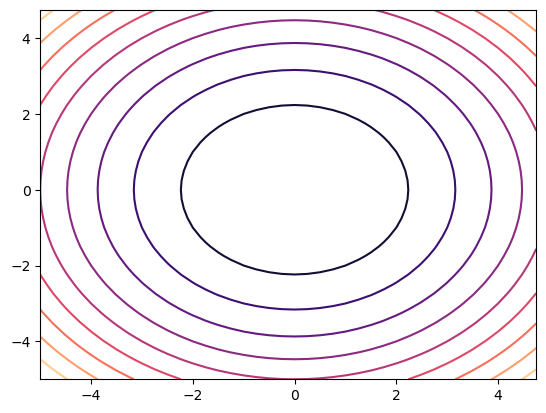

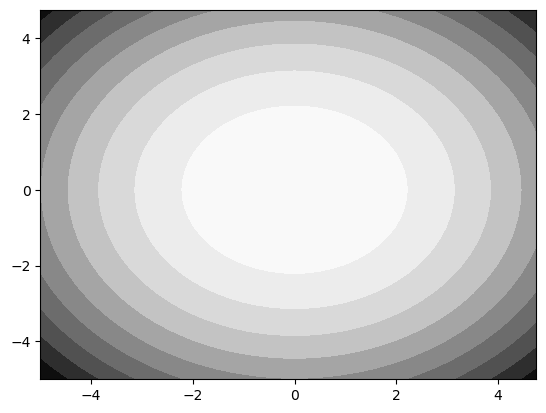

In [12]:

import numpy as np
import matplotlib.pyplot as plt
X = np.arange(-5, 5, 0.25)
Y = np.arange(-5, 5, 0.25)
X, Y = np.meshgrid(X, Y)

Z = X**2 + Y**2
fig = plt.figure(1)
plt.contour(X, Y, Z, 10, cmap='magma')
fig = plt.figure(2)
plt.contourf(X, Y, Z, 10, cmap='Greys')
plt.show()

설명한대로 마치 등고선을 위에서 본 거 같은 친구가 그려집니다. 어디서 많이 보셨을거에요.

\[상미분 방정식\]에서 위상 평면을 그릴 때 이 방식을 많이 사용하는데요, 이걸 이용하면 나중에 수치적으로 미분 방정식을 풀어서

그 결과물을 이렇게 플롯하실 수도 있습니다.

## 다각형(Polygon)

`mpl_toolkits.mplot3d`의 `art3d`라는 하위 모둘을 이용하면 다각형도 그릴 수 있습니다.

이를 위해서 우리는 `art3d`로부터 `Poly3DCollection`이라는 친구를 불러와야합니다 :

In [13]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

물론 다각형을 3차원에서 그려지며, 이 다각형을 여러 개 동시에 그리는 방법으로 다면체도 그려낼 수 있습니다. 먼저 한 번 보시죠.

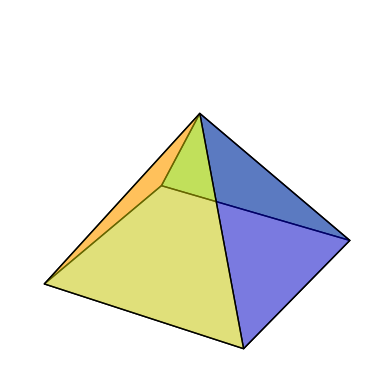

In [14]:
#우리는 피라미드 형태의 다면체를 그려보려고 합니다.


# 피라미드의 xy평면 상의 네 꼭짓점을 정의
v = [[0, 0, 0], [1, 0, 0], [1, 1, 0], [0, 1, 0]]

# 피라미드의 3차원 꼭짓점(피라미드 꼭대기)를 정의
apex = [0.5, 0.5, 1]

# 이 시점에서 우리는 피라미드의 모든 꼭짓점을 정의했는데요, 이제 이 꼭짓점들을 잇는 삼각형을 그릴겁니다.
# 이를 위해서 우리는 v에서 두 점을 뽑고, 그 점과 apex의 점을 이어서 각 삼각형들을 그릴 수 있습니다.

# s에는 이렇게 각 면의 삼각형들의 꼭짓점들이 저장됩니다.
s = [[v[i], v[(i+1) % 4], apex] for i in range(4)]

# 늘 먹던 그 맛
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

# 그리고 우리는 ax라는 axes에 다음과 같이 add_collection3d() 메소드로 다각형들을 합치는데요, 각 다각형은 보시다시피 Poly3DCollection으로 생성됩니다.
ax.add_collection3d(
    Poly3DCollection(
        [v] + s, facecolors=['grey', 'yellow', 'blue', 'green', 'red'], alpha=0.4, linewidths=1, edgecolors='black'
                                    )
                   )
# [v]는 밑면의 사각형이고, 거기다가 s에 저장된 각 점으로 정의되는 삼각형들이 이어지는거에요.

ax.grid(False) # 함수가 아니라 도형이므로 격자는 보이지 않게 합니다.
ax.axis('off') # 함수가 아니라 도형이므로 축은 보이지 않게 합니다.


plt.show()


위에는 바로 다각형을 그려서 다면체로 합쳐서 이게 잘 안보일 수도 있는데요,

메소드 `Poly3DCollection()`는 점들을 받아서, 점들을 이어서 그리는 다각형을 생성합니다. 점들은 3차원 리스트(대괄호 3개)의 형태로 전달되야합니다.

점들은 `[x, y, z]`의 형태가 되고, 이 점들이 모이면 `[[x1,y1,z1], [x2,y2,z2], ..., [xn,yn,zn] ]`의 2차원 리스트가 되는데요,

우리는 이 2차원 리스트들을 면으로 하는 다면체를 그리는거니 결국 3차원 리스트가 전달되어야하는거죠.

그리고 비로서 `add_collection3d`가 `Poly3DCollection`의 친구들을 묶어서 다면체로 만듭니다.

나머지 옵션들은 기존의 다른 옵션들과 매우 유사하므로 따로 설명 없이 넘어갑니다.

## 텍스트와 주석

위에서도 보셨다시피 텍스트, 주석 등등 여러 옵션들은 2D 플롯과 동일하게 사용 가능합니다. 몇 개만 다시 짚고 넘어갈게요.

- `ax.text(x,y,z, text)` : `x,y,z`의 좌표에 `text`의 내용을 적습니다. 
- `ax.annotate(text,xy)` 플롯의 특정 부분을 화살표로 가리킨 후, 그거에 대한 설명을 적습니다.(근데 일단 2차원에서 대부분 사용)
- `ax.set_xlabel`, `ax.set_ylabel`, `ax.set_zlabel` 각 축에 대한 텍스트를 추가
- `ax.set_title` 타이틀을 추가

## 3D 전용 옵션들

위에서부터 보셨다면 3D 플롯을 직접 하는 기능을 제외하면 나머지 타이틀이라던지 축을 나누는 등의 기능들은

기존의 2D에서와 매우 유사하다는걸 눈치채셨을건데요,

당연히 2D에서는 사용 안하는, 딱 3D의 전용 옵션들도 존재합니다. 이는 다음과 같습니다.

- `ax.view_init(elev,azim)` 3D 플롯의 시점을 변경합니다. `elev`은 0\~90으로 위아래 각도, `azim` 0\~360의 방위각
- `ax.set_box_aspect([x,y,z])` 가로세로높이의 3D 종횡비를 조절
- `ax.set_proj_type('type')` 투영 방식 변경(원근감 조절)

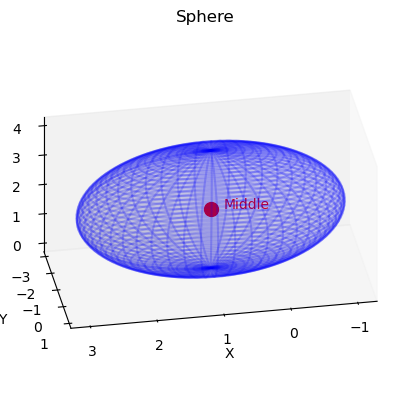

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

cx, cy, cz = 1, -1, 2
radius = 2

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

u = np.linspace(0, 2 * np.pi, 50)
v = np.linspace(0, np.pi, 50)
x = radius * np.outer(np.cos(u), np.sin(v)) + cx
y = radius * np.outer(np.sin(u), np.sin(v)) + cy
z = radius * np.outer(np.ones(np.size(u)), np.cos(v)) + cz

ax.plot_surface(x, y, z, color='b', alpha=0.1)
ax.plot_wireframe(x, y, z, color='b', alpha=0.2)
ax.scatter([cx], [cy], [cz], color='red', s=100, marker='o')
ax.text(cx-0.2, cy, cz, 'Middle', color='red')

# 이 부분의 값을 바꿔가면서 트라이해보시면 빨리 이해가 될겁니다.
ax.set_box_aspect([2, 1, 1])
ax.view_init(30,45)
ax.set_proj_type('ortho')

ax.grid(False)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Sphere')
ax.view_init(30, 80)
    
plt.show()

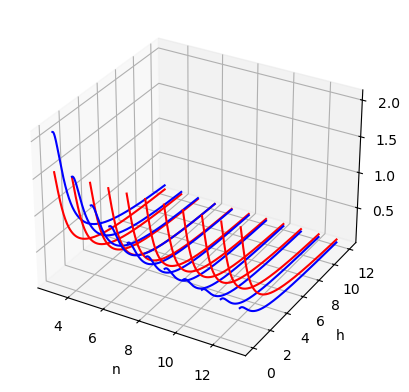

In [16]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

h = np.linspace(0.01, 12, 1000)
n = np.arange(3, 14)
alpha = np.arctan(1/h)
s = np.sqrt(h**2 + 1)

for m in n:
    ax.plot([m]*len(h), h, alpha, color='red')
    t = 2*np.sin(np.pi/m)
    beta = np.arccos((2*s**2 - t**2)/(2*s**2))
    ax.plot([m]*len(h), h, beta, color='blue')
ax.set_xlabel('n')
ax.set_ylabel('h')
plt.show()

